In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize
from src.strategy import mean_reversion_strategy, momentum_strategy
from src.visualization import plot_performance

In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


## Mean Reversion, Window = 5

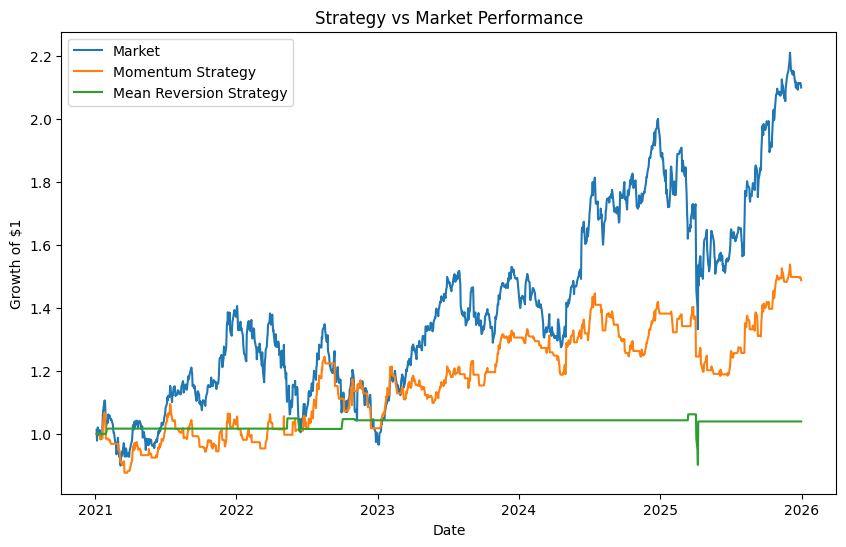

In [3]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 5)
df = momentum_strategy(df, window = 5)
df = backtest(df)

plot_performance(df)

In [4]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum,0.532690,0.180540,-0.182804,0.493227,0.520408,0.537651
2,Mean Reversion,0.130927,0.085913,-0.151435,0.471713,0.545455,0.009036


## Mean Reversion, Window = 10

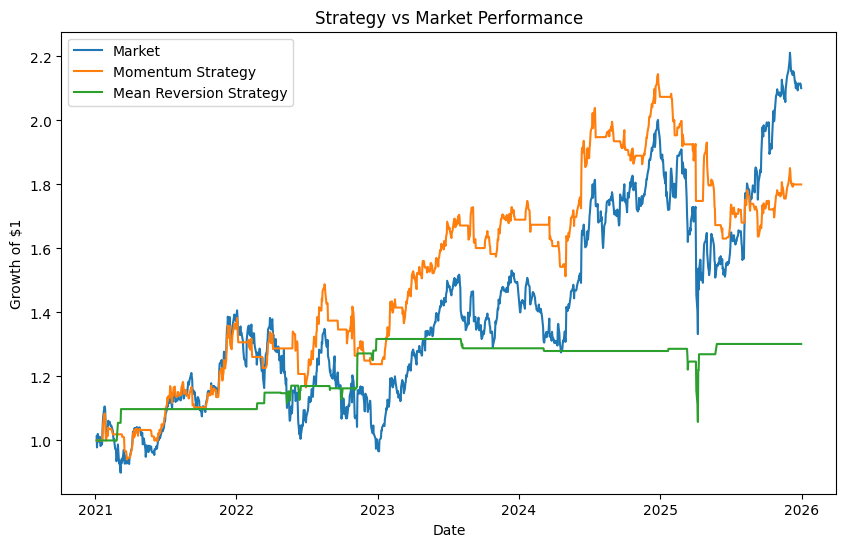

In [5]:
df = base_df.copy()
df = mean_reversion_strategy(df)
df = momentum_strategy(df)
df = backtest(df)

plot_performance(df)

In [6]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum,0.743253,0.180892,-0.239679,0.514741,0.538678,0.576807
2,Mean Reversion,0.533358,0.110174,-0.196905,0.474900,0.555556,0.037651


## Mean Reversion, Window = 20

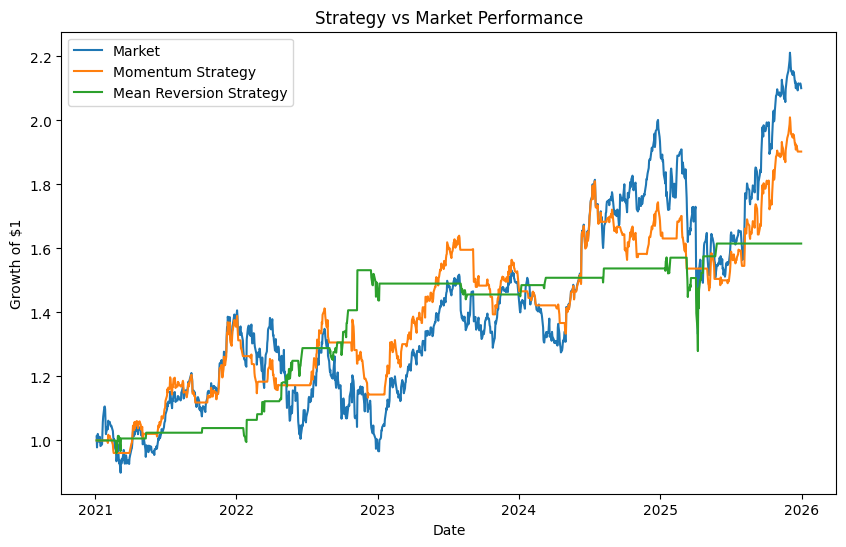

In [7]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 20)
df = momentum_strategy(df, window = 20)
df = backtest(df)

plot_performance(df)

In [8]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum,0.822887,0.175712,-0.197545,0.491633,0.51752,0.578313
2,Mean Reversion,0.766146,0.137776,-0.186215,0.475697,0.52500,0.094880


## Mean Reversion, Window = 50

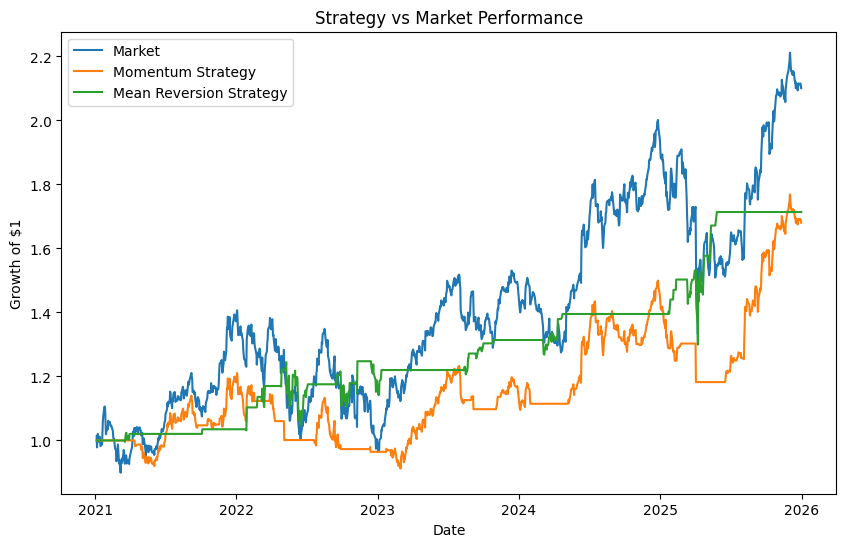

In [9]:
df = base_df.copy()
df = mean_reversion_strategy(df, window = 50)
df = momentum_strategy(df, window = 50)
df = backtest(df)

plot_performance(df)

In [10]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum,0.671191,0.179313,-0.246886,0.505976,0.530137,0.582831
2,Mean Reversion,0.766574,0.156943,-0.158242,0.494024,0.578378,0.161145


## Best MR Window, Fixed Threshold Test

Mean Reversion
Market Sharpe Ratio: 0.6742
Best Mean Reversion Strategy window: 48
Best Sharpe ratio: 0.8420



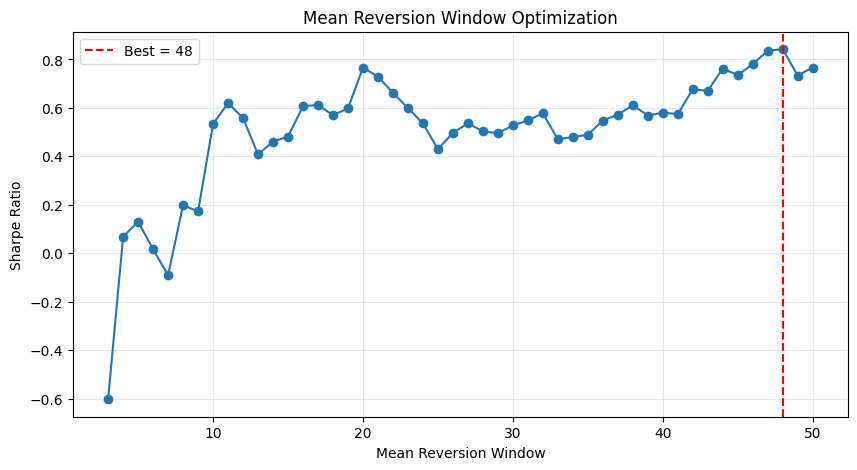

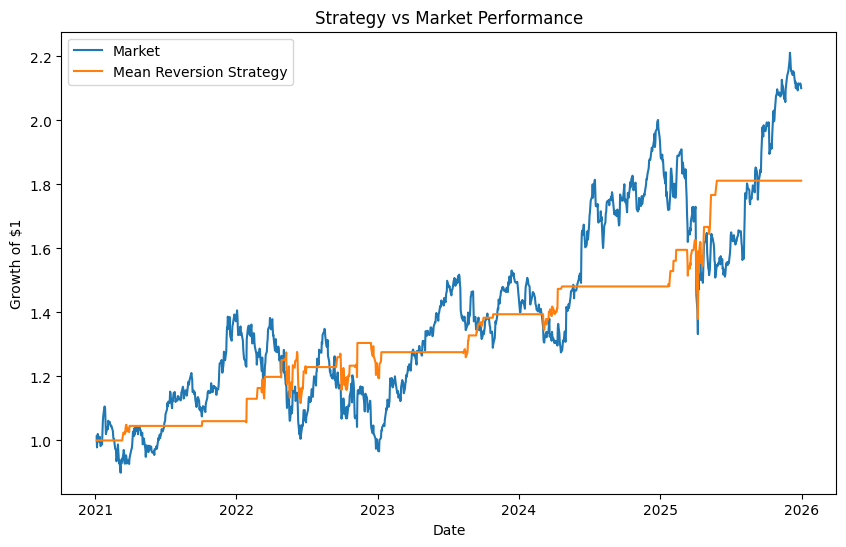

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Mean Reversion,0.842047,0.155940,-0.151435,0.495618,0.586592,0.158133


In [11]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', None, None)
]
window = range(1, 51)

optimize(df, strategy, window)

In [12]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Mean Reversion,0.842047,0.155940,-0.151435,0.495618,0.586592,0.158133


## Best MR Window & Threshold Test

Mean Reversion


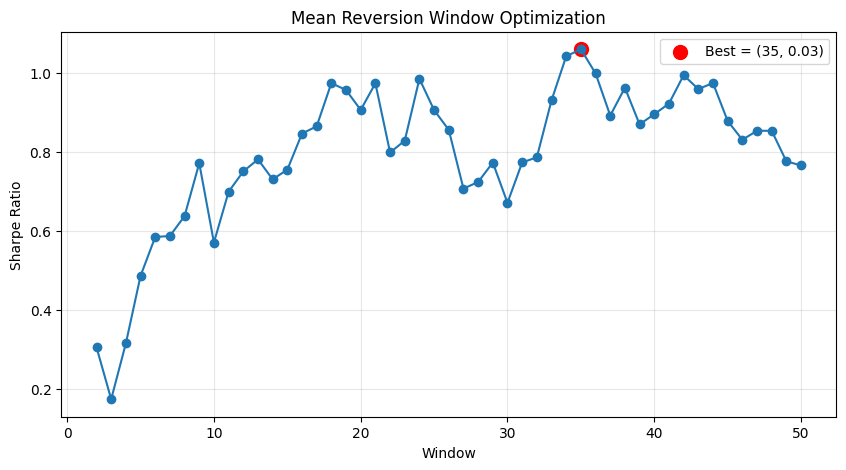

Market Sharpe Ratio: 0.6742
Best Mean Reversion Strategy window: 35
Best threshold: 3%
Best Sharpe ratio: 1.0611



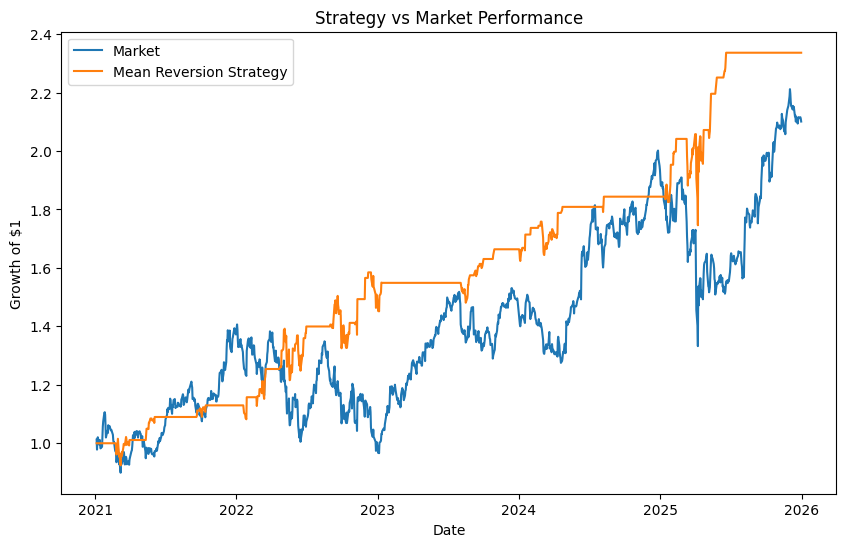

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Mean Reversion,1.061114,0.174839,-0.151435,0.502789,0.570423,0.243976


In [13]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(1, 101), None)
]
window = range(1, 51)

optimize(df, strategy, window, windowplot=True)

## Best Momentum vs Best Mean Reversion

Mean Reversion


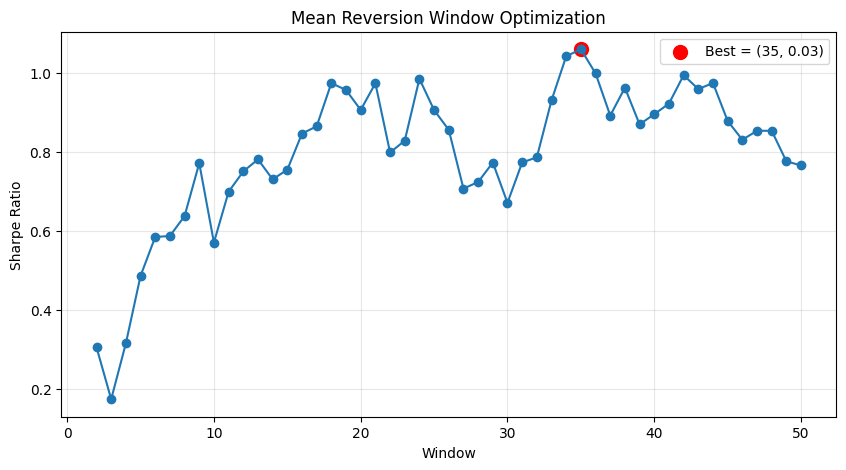

Market Sharpe Ratio: 0.6742
Best Mean Reversion Strategy window: 35
Best threshold: 3%
Best Sharpe ratio: 1.0611

Momentum
Market Sharpe Ratio: 0.6742
Best Momentum Strategy window: 6
Best Sharpe ratio: 0.9757



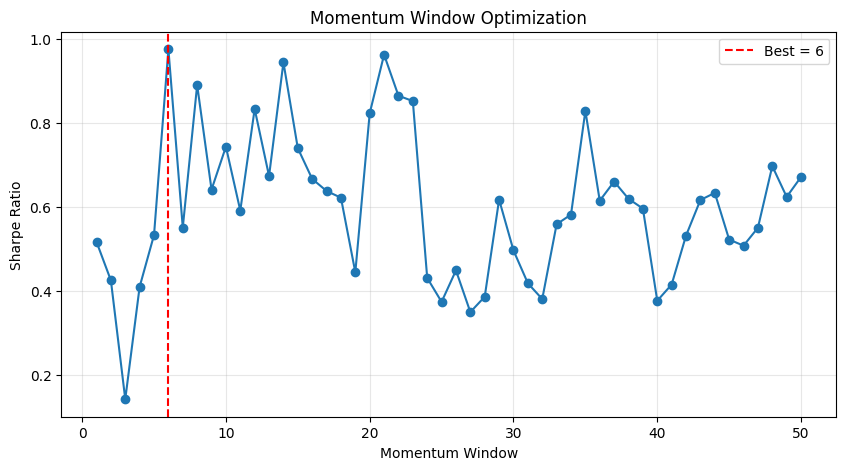

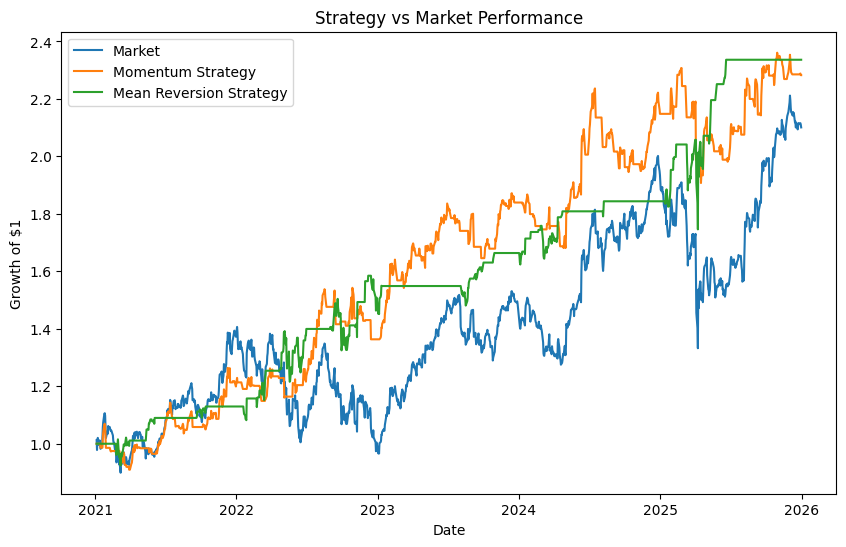

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Mean Reversion,1.061114,0.174839,-0.151435,0.502789,0.570423,0.243976
2,Momentum,0.975684,0.188123,-0.173479,0.508367,0.533716,0.560241


In [14]:
df = base_df.copy()
strategy = [
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(1, 101), None),
    ('Momentum', momentum_strategy, 'mom', None, None)
]
window = range(1, 51)

optimize(df, strategy, window)